# Day 2 - Week 5: DBSCAN & Hierarchical Clustering 

## Importing

In [5]:
from IPython.display import Image, display


## 1. K-Means Clustering
### 1.1 What is K-Means?

K-Means is one of the most popular clustering algorithms.

Its goal is to divide the dataset into K clusters.

The basic idea is:

1. Choose the number of clusters K.
2. Initialize K centroids.
3. Assign every point to the closest centroid.
4. Recalculate the centroids.
5. Repeat until the clusters stabilize.

### 1.2 K-Means Visualization

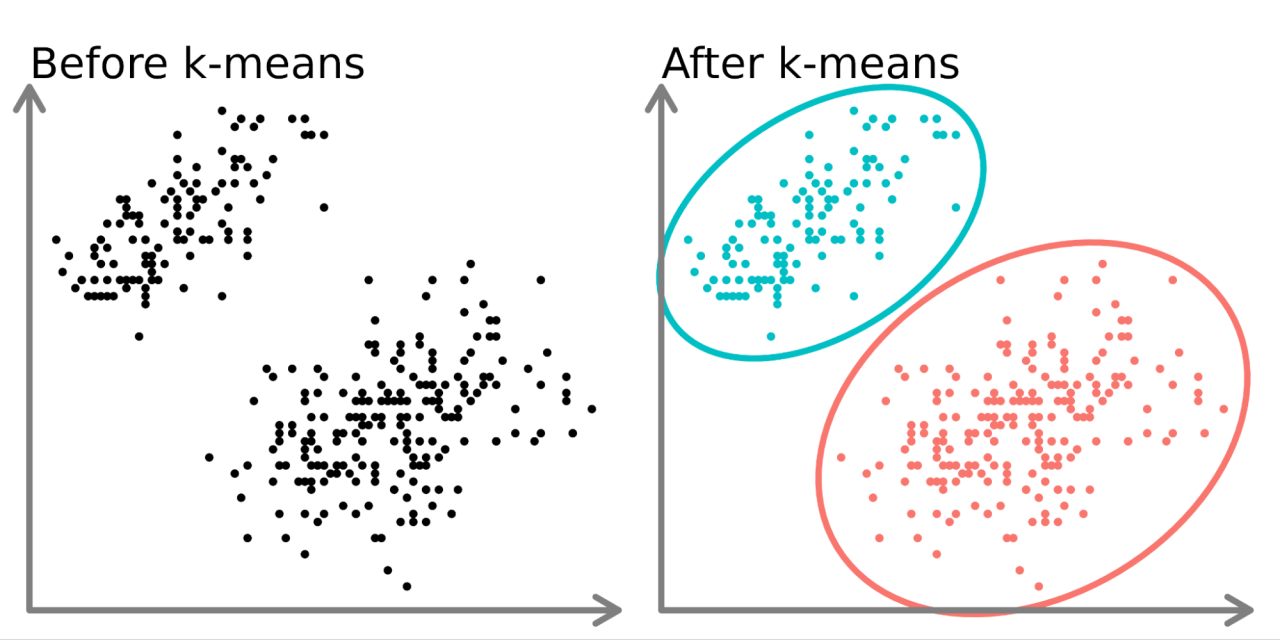

In [6]:
display(Image(filename='assets/k_means.png'))

### 1.3 Example with Scikit-Learn

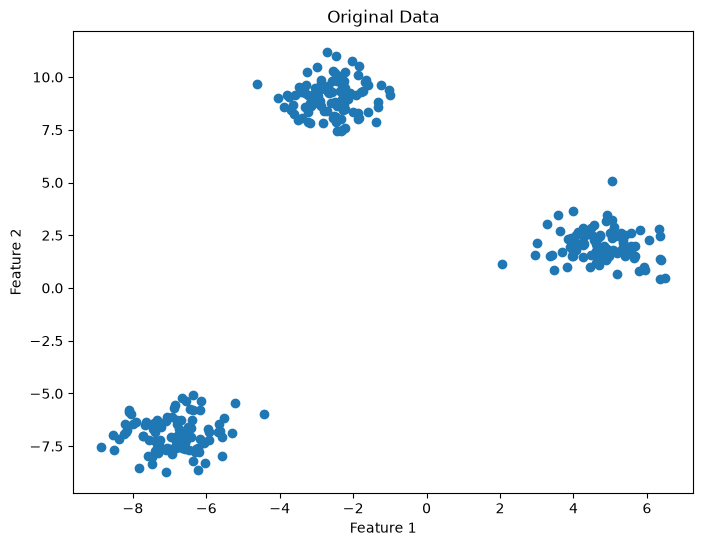

In [7]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.8,
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


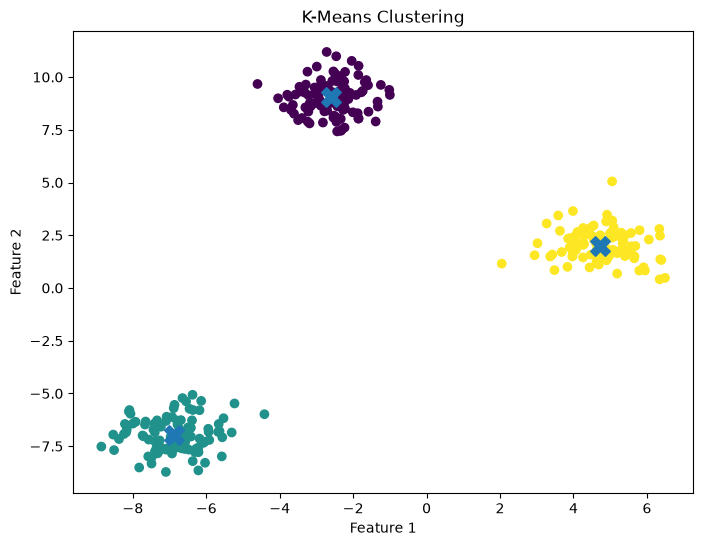

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 1.4 Limitations of K-Means

#### K-Means is powerful, but it has several important limitations.

##### Limitation 1 — We must choose K

We need to specify:
```python

from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
```
before training.

If we don't know the number of clusters, we need another technique such as:

- Elbow Method
- Silhouette Score

##### Limitation 2 — Cluster Shape

K-Means works best when clusters are approximately:

- Round
- Compact
- Similar in size

It may perform poorly with irregularly shaped clusters.

##### Limitation 3 — Outliers

K-Means assigns every point to a cluster.

Even if a point is very far away from all other observations, it will still be assigned to one of the clusters.

This means K-Means does not explicitly identify noise.

## 2. DBSCAN
### 2.1 What is DBSCAN?

DBSCAN stands for:

Density-Based Spatial Clustering of Applications with Noise

Unlike K-Means, DBSCAN does not ask:

> "How many clusters do you want?"

Instead, it asks:

> "Where are the dense regions of the data?"

Points that belong to dense regions form clusters.

Points in sparse regions can be classified as noise.

### 2.2 DBSCAN Visualization

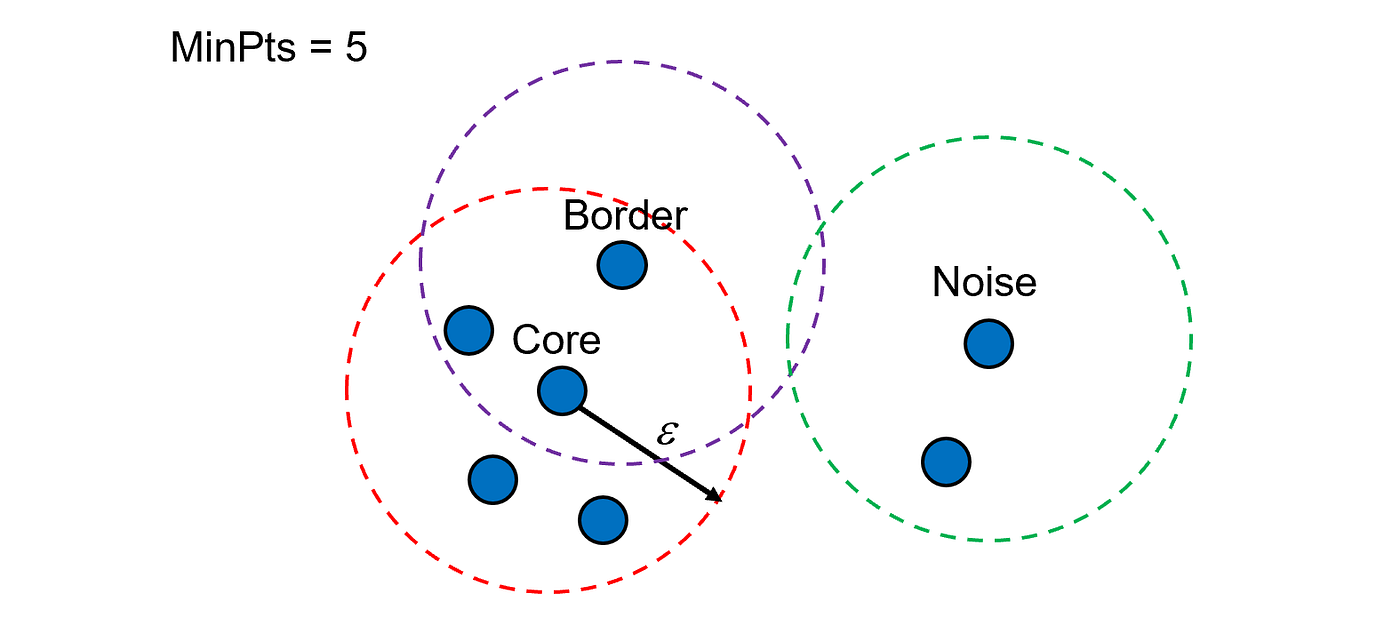

In [9]:
display(Image(filename='assets/DBSCAN.png'))

The important idea is that DBSCAN can discover clusters with irregular shapes.  
K-Means may struggle with this shape, while DBSCAN can identify it as one cluster.

### 2.3 DBSCAN Parameters

DBSCAN has two important parameters:
```python
DBSCAN(
    eps=0.5,
    min_samples=5
)
```

### 2.4 eps

`eps` represents the maximum distance between two points for them to be considered neighbors.

In simple words:

> eps controls how close points need to be to each other.

### 2.5 eps Visualization

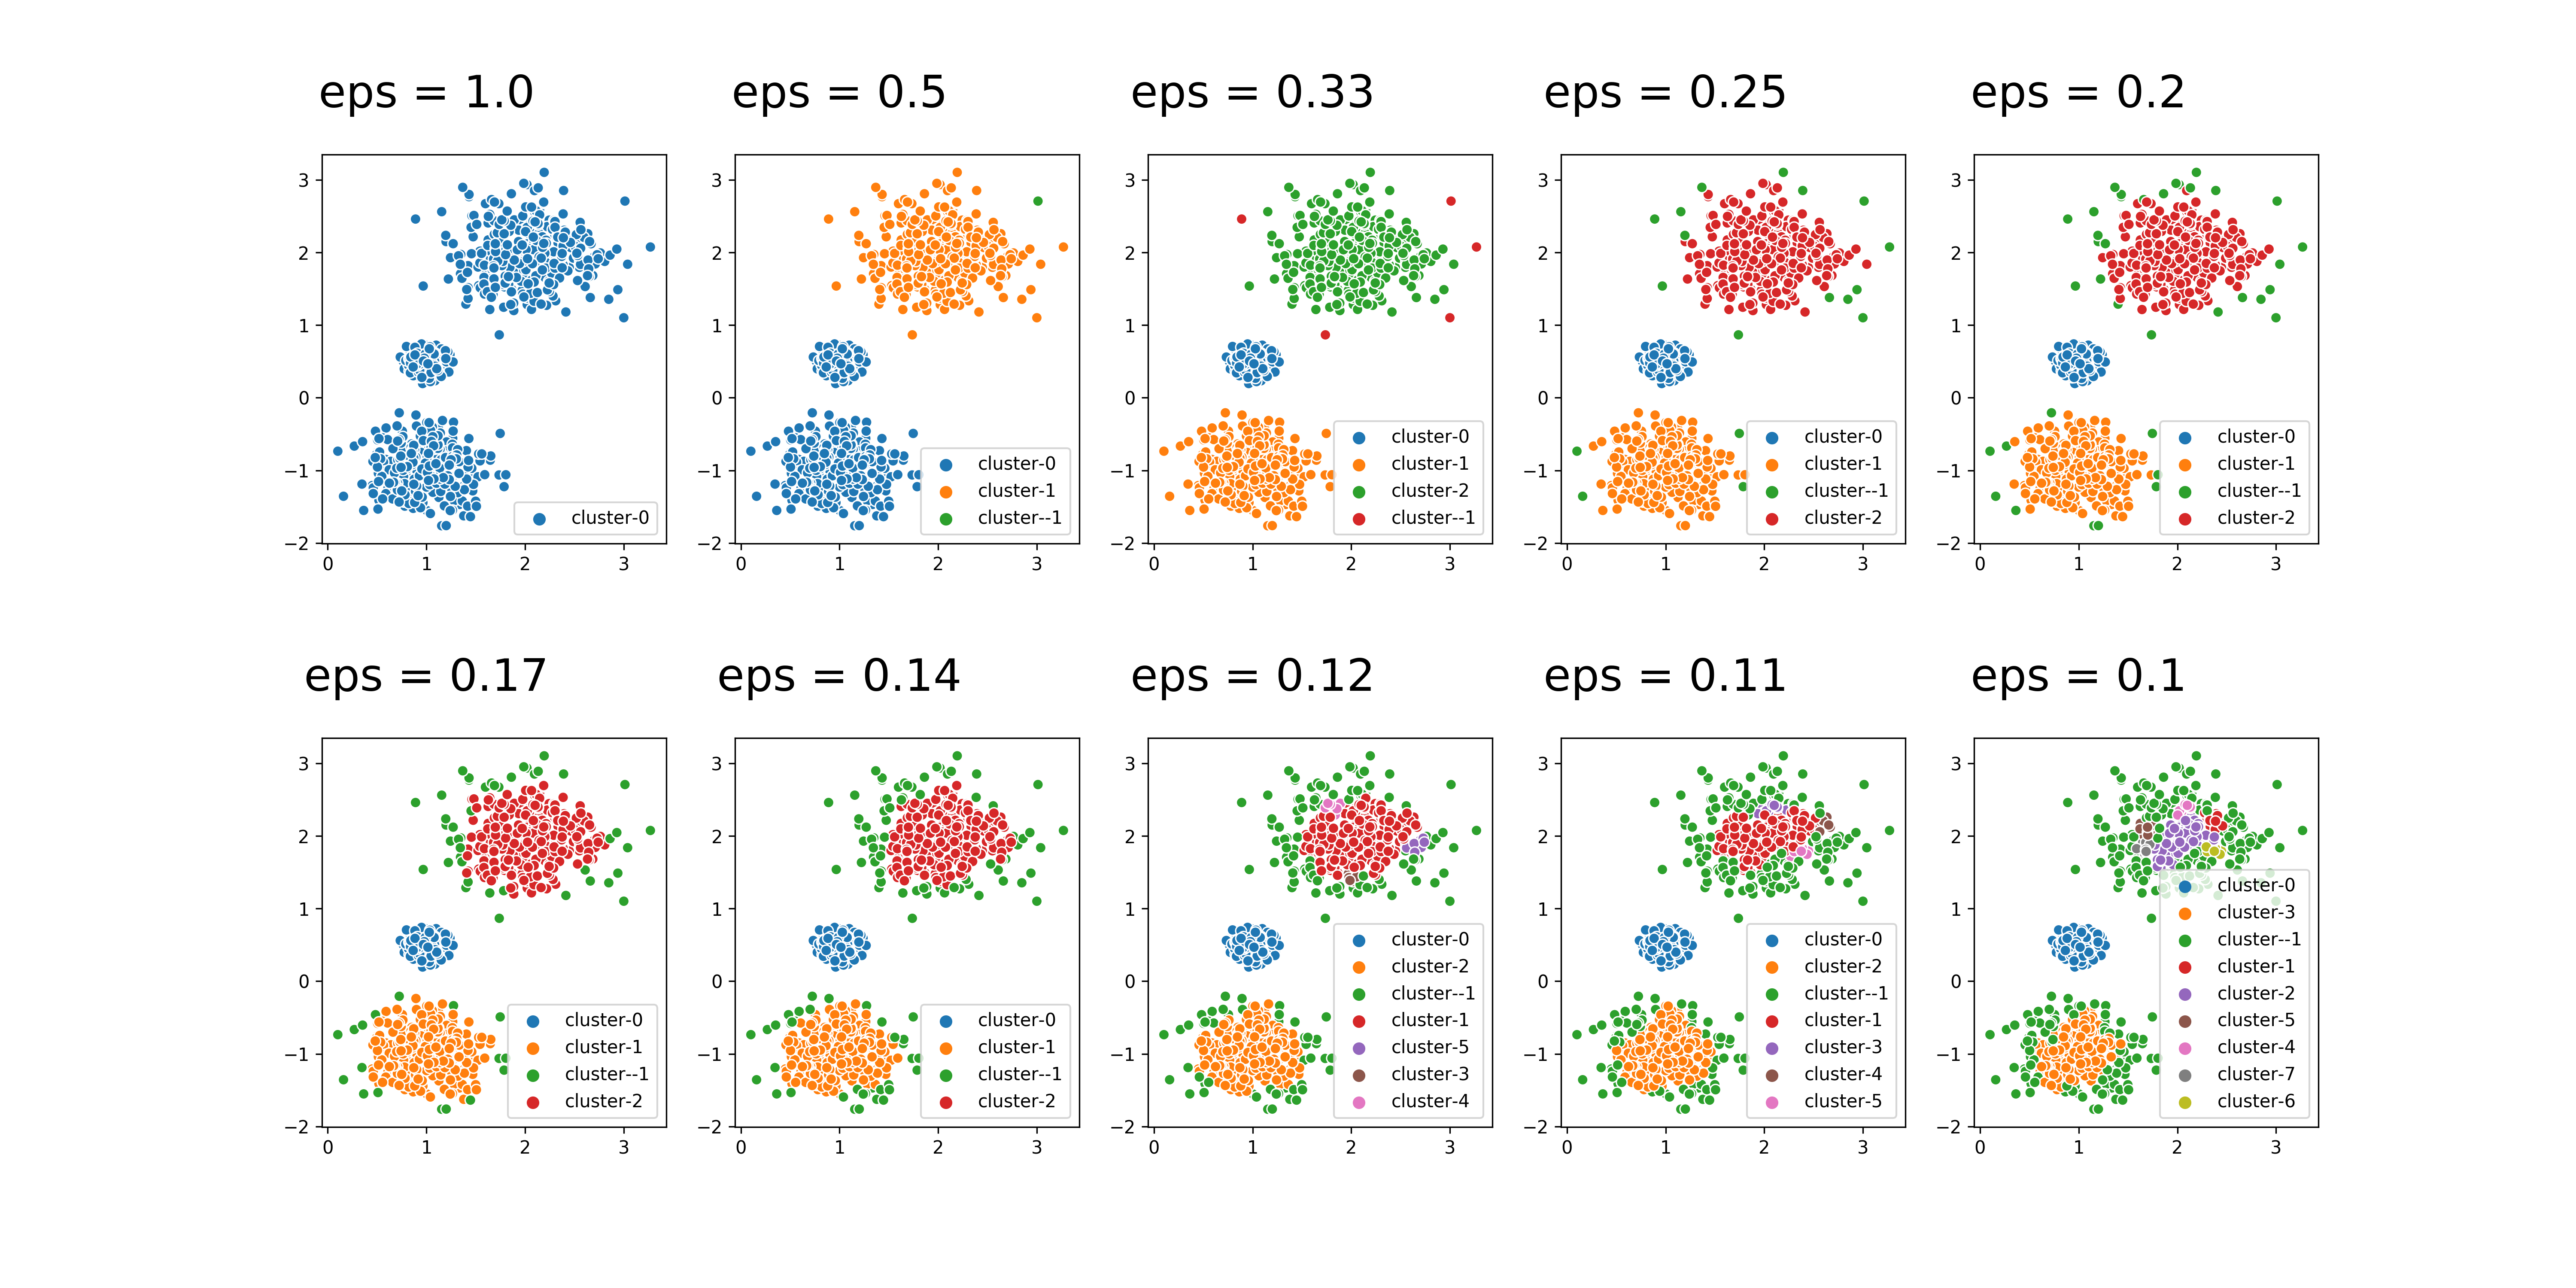

In [10]:
display(Image(filename='assets/eps.png'))

#### What happens when `eps` is too small?

If:
``` python
eps = 0.1
```
the neighborhood is very small.

Many points may not have enough neighbors.

Result:

- More noise
- More small clusters
#### What happens when `eps` is too large?

If:
```python
eps = 2.0
```
the neighborhood becomes very large.

Different clusters may become connected.

Result:

- Separate clusters may merge
- Too few clusters may be detected

Therefore, choosing a good `eps` is important.

### 2.6 min_samples

`min_samples` controls the minimum number of nearby points required for a dense region.

For example:
```python 
DBSCAN(
    eps=0.5,
    min_samples=5
)
```
means that the algorithm requires sufficient nearby observations to consider an area dense.

Increasing `min_samples` makes DBSCAN more strict.

### 2.7 Running DBSCAN

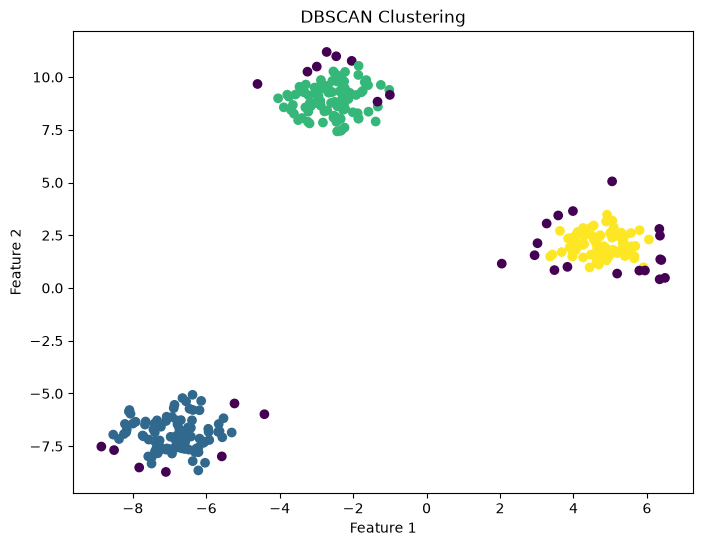

In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=dbscan_labels
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 2.8 Understanding Noise

One of the most useful features of DBSCAN is its ability to identify noise.

DBSCAN uses:

> -1

to represent noise points.

We can count the noise points:
```python
import numpy as np


noise_count = np.sum(dbscan_labels == -1)


print("Number of noise points:", noise_count)
```
We can also calculate the number of clusters:
```python
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)


print("Number of clusters:", n_clusters)
```
The subtraction is necessary because `-1` represents noise, not a real cluster.

## 3. Hierarchical Clustering
### 3.1 What is Hierarchical Clustering?

Hierarchical Clustering creates a hierarchy of clusters.

It starts with:

> Every point = its own cluster

Then it repeatedly merges the closest clusters.

For example:

> A   B   C   D

First:

> AB   C   D

Then:

> AB   CD

Finally:

> ABCD

This creates a tree-like structure.

### 3.2 Hierarchical Clustering Visualization

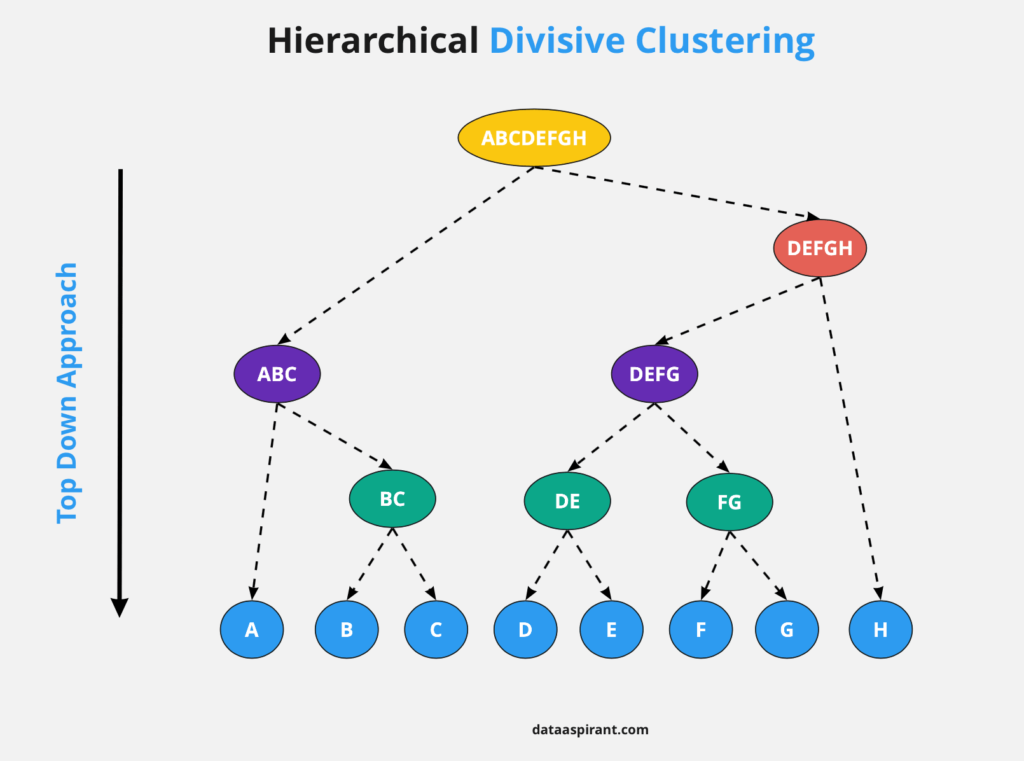

In [13]:
display(Image(filename='assets/hierarchical_clustering.png'))

The main visualization is called a:

#### *Dendrogram*

A dendrogram shows how clusters are progressively merged.

### 3.2 Creating a Dendrogram

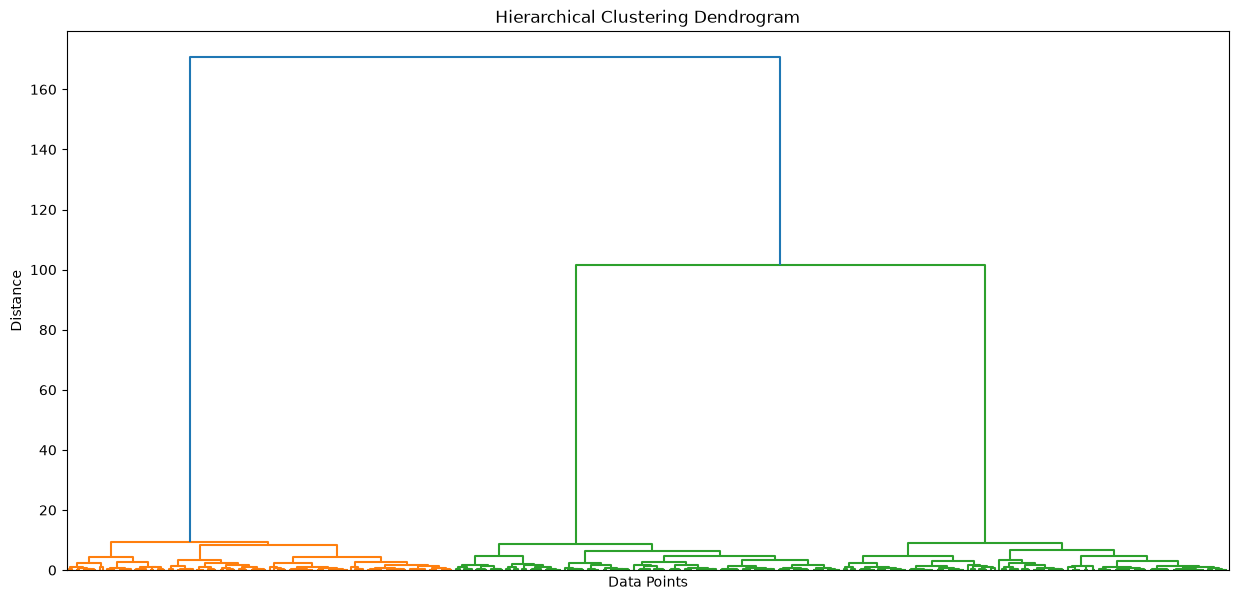

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(
    X,
    method="ward"
)
plt.figure(figsize=(15, 7))

dendrogram(
    Z,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### 3.3 Why Hierarchical Clustering Doesn't Need K Initially

K-Means starts with:

> K = 3

Hierarchical Clustering starts with:

> Every point is its own cluster

and builds the complete hierarchy.

After seeing the dendrogram, we can decide where to "cut" the tree.

Therefore, we don't have to choose the final number of clusters before constructing the hierarchy.

### 3.4 Linkage Methods

Hierarchical Clustering has different ways of calculating the distance between clusters.

Common methods include:

- single
- complete
- average
- ward

For example:
```python
Z = linkage(X, method="ward")
```
#### Ward
Ward tries to merge clusters while minimizing the increase in within-cluster variance.

It is commonly useful when clusters are relatively compact.